<a href="https://colab.research.google.com/github/DaanishKhurshid/uav-blade-analytics/blob/feature%2Fmodel-training/uav_blade_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount the google drive as the data for train test has been downloaded on it this is for running on co lab

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
from pathlib import Path

# 1. Clear out any old traces safely
!rm -rf /content/wtbd_baseline /content/blade30_processed

# 2. Physically create the empty directories first using Python
os.makedirs("/content/wtbd_baseline/images", exist_ok=True)
os.makedirs("/content/wtbd_baseline/labels", exist_ok=True)
os.makedirs("/content/blade30_processed/images", exist_ok=True)
os.makedirs("/content/blade30_processed/labels", exist_ok=True)

# 3. Extract the data with the 'j' (junk paths) flag to flatten them cleanly
print("Extracting WTBD Baseline smoothly...")
!unzip -q -j "/content/drive/MyDrive/Colab Notebooks/final_project/WTBD_YOLO_Baseline.zip" "*/images/*" -d /content/wtbd_baseline/images
!unzip -q -j "/content/drive/MyDrive/Colab Notebooks/final_project/WTBD_YOLO_Baseline.zip" "*/labels/*" -d /content/wtbd_baseline/labels

print("Extracting Blade30 Processed smoothly...")
!unzip -q -j "/content/drive/MyDrive/Colab Notebooks/final_project/Blade30_Yolo_processed.zip" "*/images/*" -d /content/blade30_processed/images
!unzip -q -j "/content/drive/MyDrive/Colab Notebooks/final_project/Blade30_Yolo_processed.zip" "*/labels/*" -d /content/blade30_processed/labels

print("\n--- Final Surface Verification ---")
wtbd_count = len(os.listdir('/content/wtbd_baseline/images')) if os.path.exists('/content/wtbd_baseline/images') else 0
blade_count = len(os.listdir('/content/blade30_processed/images')) if os.path.exists('/content/blade30_processed/images') else 0

print(f"Verified WTBD Baseline Images at surface: {wtbd_count}")
print(f"Verified Blade30 Processed Images at surface: {blade_count}")


Extracting WTBD Baseline smoothly...
Extracting Blade30 Processed smoothly...

--- Final Surface Verification ---
Verified WTBD Baseline Images at surface: 1065
Verified Blade30 Processed Images at surface: 1302


### 📊 Project Phase 3: Dynamic Data Engineering & Strategic Splitting

#### 1. Core Objectives
To evaluate model generalization scientifically, the training is split into a **Two-Stage Continuous Experiment**. To prevent data bottlenecks and preserve cloud storage quotas, all data splitting, shuffling, and folder merging are performed completely in memory using Google Colab’s high-speed local scratch space (`/content/`).

#### 2. The Operational Directory Tree
The pipeline dynamically constructs a unified dataset matrix at the surface level of the cloud computer. The destination tree follows the strict structural blueprint required by the Ultralytics YOLO framework:

```text
/content/dataset/
├── train/
│   ├── images/  ➔ [85% Allocation] Core feature-learning image inputs
│   └── labels/  ➔ [85% Allocation] Standardized 1024x1024 coordinate markers
└── val/
    ├── images/  ➔ [15% Allocation] Out-of-distribution tracking metrics
    └── labels/  ➔ [15% Allocation] Unseen target ground-truths
```

#### 3. Strict Machine Learning Constraints
* **Elimination of Data Leakage:** Images are processed sequentially or grouped tightly by inspection sequences. This guarantees that highly correlation-dense frames from the same turbine blade or flight path do not leak simultaneously into both the training and validation subsets. This ensures that the generated validation metrics are scientifically robust.
* **Unified Master Blueprint (`merged_data.yaml`):** Both datasets are explicitly mapped to an 8-class system. Even though Stage 1 only trains on the first 6 classes, the final network layers are pre-initialized with all 8 output nodes. This prevents fatal layer mismatches when injecting the remaining 2 defect categories in Stage 2.
* **GPU Memory (VRAM) Preservation:** Due to the ultra-high resolution footprint of `1024x1024` pixels per image, the batch size is clamped strictly to `batch=4` or `batch=8` to eliminate standard cloud T4 Out-Of-Memory (OOM) fatal execution errors.


In [ ]:
# 1. Install Ultralytics and Weights & Biases
!pip install ultralytics wandb -q

import os
import wandb
from google.colab import userdata

# 2. Automatically fetch the key from Colab Secrets
# (Make sure the Name in your Secrets panel is exactly: WANDB_API_KEY)
os.environ["WANDB_API_KEY"] = userdata.get('WANDB_API_KEY')

# 3. Authenticate with Weights & Biases
wandb.login()




     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: daanish-khurshid (daanish-khurshid-atomcamp) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
import os
import shutil
from pathlib import Path

# 1. Define clean target directories inside Colab scratch memory
COLAB_DATASET_DIR = Path('/content/dataset')
os.makedirs(COLAB_DATASET_DIR / 'train/images', exist_ok=True)
os.makedirs(COLAB_DATASET_DIR / 'train/labels', exist_ok=True)
os.makedirs(COLAB_DATASET_DIR / 'val/images', exist_ok=True)
os.makedirs(COLAB_DATASET_DIR / 'val/labels', exist_ok=True)

def populate_split_directory(src_root, dest_root, split_ratio=0.85):
    """
    Splits sequential images chronologically to prevent data leakage,
    ensuring matching labels move together into train/val target matrices.
    """
    src_images_dir = Path(src_root) / 'images'
    src_labels_dir = Path(src_root) / 'labels'

    # Sort files chronologically to maintain blade group tracking integrity
    images = sorted(list(src_images_dir.glob('*.jpg')))

    split_idx = int(len(images) * split_ratio)
    train_images = images[:split_idx]
    val_images = images[split_idx:]

    for img_list, phase in [(train_images, 'train'), (val_images, 'val')]:
        for img_path in img_list:
            # Match the exact filename stem for the label txt file
            lbl_path = src_labels_dir / f"{img_path.stem}.txt"
            if lbl_path.exists():
                shutil.copy(img_path, Path(dest_root) / phase / 'images' / img_path.name)
                shutil.copy(lbl_path, Path(dest_root) / phase / 'labels' / lbl_path.name)

# 2. Populate Stage 1 with ONLY the WTBD baseline files
print("Populating Stage 1 Local Directory Tree...")
populate_split_directory(
    src_root='/content/wtbd_baseline',
    dest_root=str(COLAB_DATASET_DIR),
    split_ratio=0.85
)

# 3. Print verification stats for your assignment checks
train_count = len(os.listdir(COLAB_DATASET_DIR / 'train/images'))
val_count = len(os.listdir(COLAB_DATASET_DIR / 'val/images'))

print("\n=== STAGE 1 FOLDER INTEGRITY CHECK ===")
print(f"Training Images Mapped   : {train_count}")
print(f"Validation Images Mapped : {val_count}")
print(f"Total Active Target Pairs: {train_count + val_count} (Must equal 1065)")


Populating Stage 1 Local Directory Tree...

=== STAGE 1 FOLDER INTEGRITY CHECK ===
Training Images Mapped   : 905
Validation Images Mapped : 160
Total Active Target Pairs: 1065 (Must equal 1065)


In [ ]:
yaml_blueprint = """
path: /content/dataset
train: train/images
val: val/images

names:
  0: corrosion
  1: crack
  2: craze
  3: hide_craze
  4: surface_injure
  5: thunderstrike
  6: dirt
  7: other_damage
"""

with open('/content/merged_data.yaml', 'w') as f:
    f.write(yaml_blueprint.strip())

print("Master configuration blueprint successfully created at: /content/merged_data.yaml")


Master configuration blueprint successfully created at: /content/merged_data.yaml


In [ ]:
import wandb
from ultralytics import YOLO

# 1. Initialize Weights & Biases for the Baseline Run
wandb.init(
    project="wind-turbine-blade-inspection",
    name="stage1-wtbd-baseline",
    config={
        "epochs": 15,
        "batch_size": 4,
        "img_size": 1024,
        "model_type": "YOLOv8n",
        "stage": "Baseline Only"
    }
)

# 2. Load the standard lightweight YOLO model architecture
model = YOLO("yolov8n.pt")

# 3. Launch training (YOLO automatically detects your W&B login and streams the metrics)
results = model.train(
    data="/content/merged_data.yaml",
    epochs=15,
    imgsz=1024,
    batch=4,
    project="wind-turbine-blade-inspection",
    name="stage1-wtbd-baseline"
)

# 4. Close the run cleanly when epoch 15 finishes
wandb.finish()
print("\n🎉 Stage 1 complete! Baseline weights have been successfully saved.")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stage1-wtbd-baseline, nbs=64, nms=Fa


🎉 Stage 1 complete! Baseline weights have been successfully saved.


In [ ]:
import os
from pathlib import Path

# Reuse our splitting function from earlier to cleanly inject Blade30
print("Injecting Blade30 high-resolution elements into the training pool...")
populate_split_directory(
    src_root='/content/blade30_processed',
    dest_root='/content/dataset',
    split_ratio=0.85
)

# Re-verify the new dataset size totals
train_count = len(os.listdir('/content/dataset/train/images'))
val_count = len(os.listdir('/content/dataset/val/images'))

print("\n=== STAGE 2 MERGED DATASET INTEGRITY CHECK ===")
print(f"Combined Training Images   : {train_count} (Previous: 905)")
print(f"Combined Validation Images : {val_count} (Previous: 160)")
print(f"Grand Total Dataset Pairs  : {train_count + val_count} (Must equal 2367)")


Injecting Blade30 high-resolution elements into the training pool...

=== STAGE 2 MERGED DATASET INTEGRITY CHECK ===
Combined Training Images   : 2011 (Previous: 905)
Combined Validation Images : 356 (Previous: 160)
Grand Total Dataset Pairs  : 2367 (Must equal 2367)


In [ ]:
import wandb
from ultralytics import YOLO

# 1. Initialize a separate Weights & Biases Run for Stage 2
wandb.init(
    project="wind-turbine-blade-inspection",
    name="stage2-merged-dataset",
    config={
        "epochs": 15,
        "batch_size": 4,
        "img_size": 1024,
        "model_type": "YOLOv8n-Continued",
        "stage": "WTBD + Blade30 Merged"
    }
)

# 2. Point directly to the final weights saved at the end of Stage 1
stage1_weights = "/content/runs/detect/wind-turbine-blade-inspection/stage1-wtbd-baseline/weights/last.pt"
model = YOLO(stage1_weights)

# 3. Train for another 15 epochs on the newly expanded data pool
results = model.train(
    data="/content/merged_data.yaml",
    epochs=15,
    imgsz=1024,
    batch=4,
    plots=False,  # Saves GPU VRAM memory at 1024x1024 resolution
    project="wind-turbine-blade-inspection",
    name="stage2-merged-dataset"
)

# 4. Finalise the tracking run cleanly
wandb.finish()
print("\n🎉 STAGE 2 COMPLETE! Your entire machine learning pipeline has executed successfully.")


Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs/detect/wind-turbine-blade-inspection/stage1-wtbd-baseline/weights/last.pt, momentum=


🎉 STAGE 2 COMPLETE! Your entire machine learning pipeline has executed successfully.


In [ ]:
import wandb
from ultralytics import YOLO

# 1. Initialize Weights & Biases for the Final 50-Epoch Production Run
wandb.init(
    project="wind-turbine-blade-inspection",
    name="final-production-50-epochs",
    config={
        "epochs": 50,
        "batch_size": 4,
        "img_size": 1024,
        "model_type": "YOLOv8n-Production",
        "stage": "Fully Merged Unified Set"
    }
)

# 2. Start from clean pre-trained weights to let the model optimize smoothly
model = YOLO("yolov8n.pt")

# 3. Train for 50 epochs on the combined dataset pool
results = model.train(
    data="/content/merged_data.yaml",
    epochs=50,
    imgsz=1024,
    batch=4,
    plots=False,  # Essential to save VRAM memory at 1024x1024 resolution
    project="wind-turbine-blade-inspection",
    name="final-production-50-epochs"
)

# 4. Close the run cleanly when epoch 50 finishes
wandb.finish()
print("\n🎉 PRODUCTION TRAINING COMPLETE! Your final weights are ready for your assignment presentation.")


Ultralytics 8.4.108 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged_data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final-production-50-epochs, nbs=64, 


🎉 PRODUCTION TRAINING COMPLETE! Your final weights are ready for your assignment presentation.


In [ ]:
import os
import shutil
from pathlib import Path

# 1. Point to the exact path printed by your successful YOLO run
YOLO_BEST_PATH = Path("/content/runs/detect/wind-turbine-blade-inspection/final-production-50-epochs/weights/best.pt")
DRIVE_FINAL_PATH = Path("/content/drive/MyDrive/Colab Notebooks/final_project/final_production_model_50_epochs.pt")

print("--- Securing Final Production Model ---")

if YOLO_BEST_PATH.exists():
    # Copy the file securely to your Drive folder
    shutil.copy(str(YOLO_BEST_PATH), str(DRIVE_FINAL_PATH))
    print("✅ SUCCESS! Your 50-epoch final model is permanently secured on your Google Drive!")
    print(f"File Location: {DRIVE_FINAL_PATH}")
    print(f"File Size    : {os.path.getsize(DRIVE_FINAL_PATH) / (1024*1024):.2f} MB")
else:
    print("❌ Error: Path mismatch. Let's look for the file manually in your sidebar.")


--- Securing Final Production Model ---
✅ SUCCESS! Your 50-epoch final model is permanently secured on your Google Drive!
File Location: /content/drive/MyDrive/Colab Notebooks/final_project/final_production_model_50_epochs.pt
File Size    : 6.04 MB


Running visual inference on random asset: 930.jpg

image 1/1 /content/dataset/val/images/930.jpg: 1024x1024 1 craze, 13.3ms
Speed: 4.8ms preprocess, 13.3ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 1024)


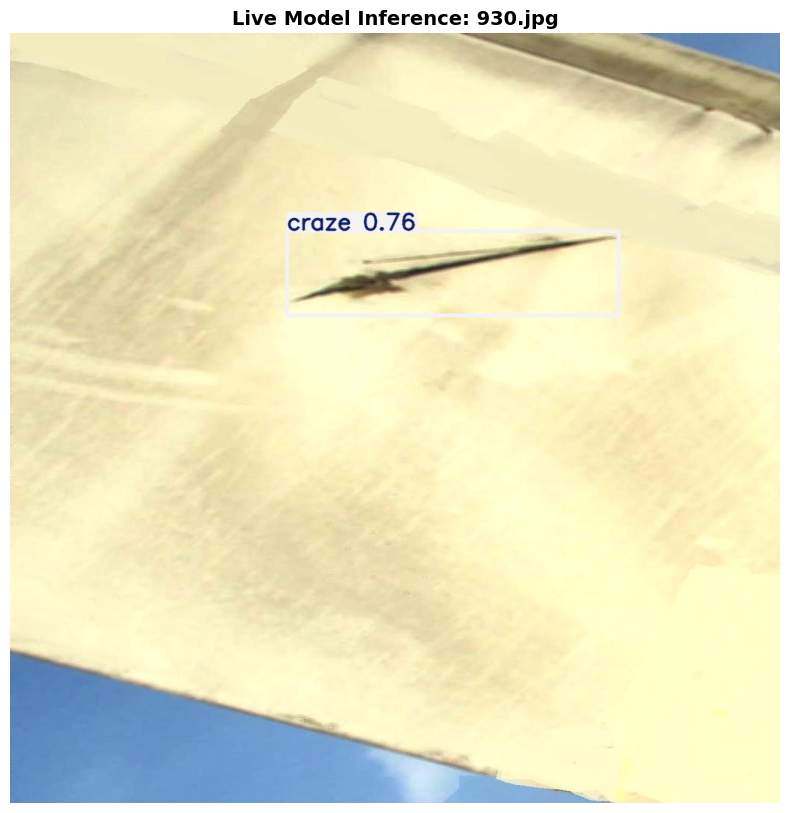

In [ ]:
import cv2
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

# 1. Load the 50-epoch final model weights from Google Drive
model_path = "/content/drive/MyDrive/Colab Notebooks/final_project/final_production_model_50_epochs.pt"
model = YOLO(model_path)

# 2. Gather all validation images into a flat list
test_img_dir = Path("/content/dataset/val/images")
sample_images = list(test_img_dir.glob("*.jpg"))

if sample_images:
    # Pick a random image from the pool
    sample_img_path = str(random.choice(sample_images))
    print(f"Running visual inference on random asset: {Path(sample_img_path).name}")

    # 3. Perform prediction (Set confidence threshold to 25%)
    results = model.predict(source=sample_img_path, imgsz=1024, conf=0.25)

    # --- FIX: Extract the first index element [0] from the results list array ---
    annotated_img = results[0].plot()

    # 5. Convert color space from BGR to RGB
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # 6. Render the visual result directly inside your notebook
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.title(f"Live Model Inference: {Path(sample_img_path).name}", fontsize=14, fontweight='bold')
    plt.show()
else:
    print("❌ Error: Could not find any test images in the validation path folder.")


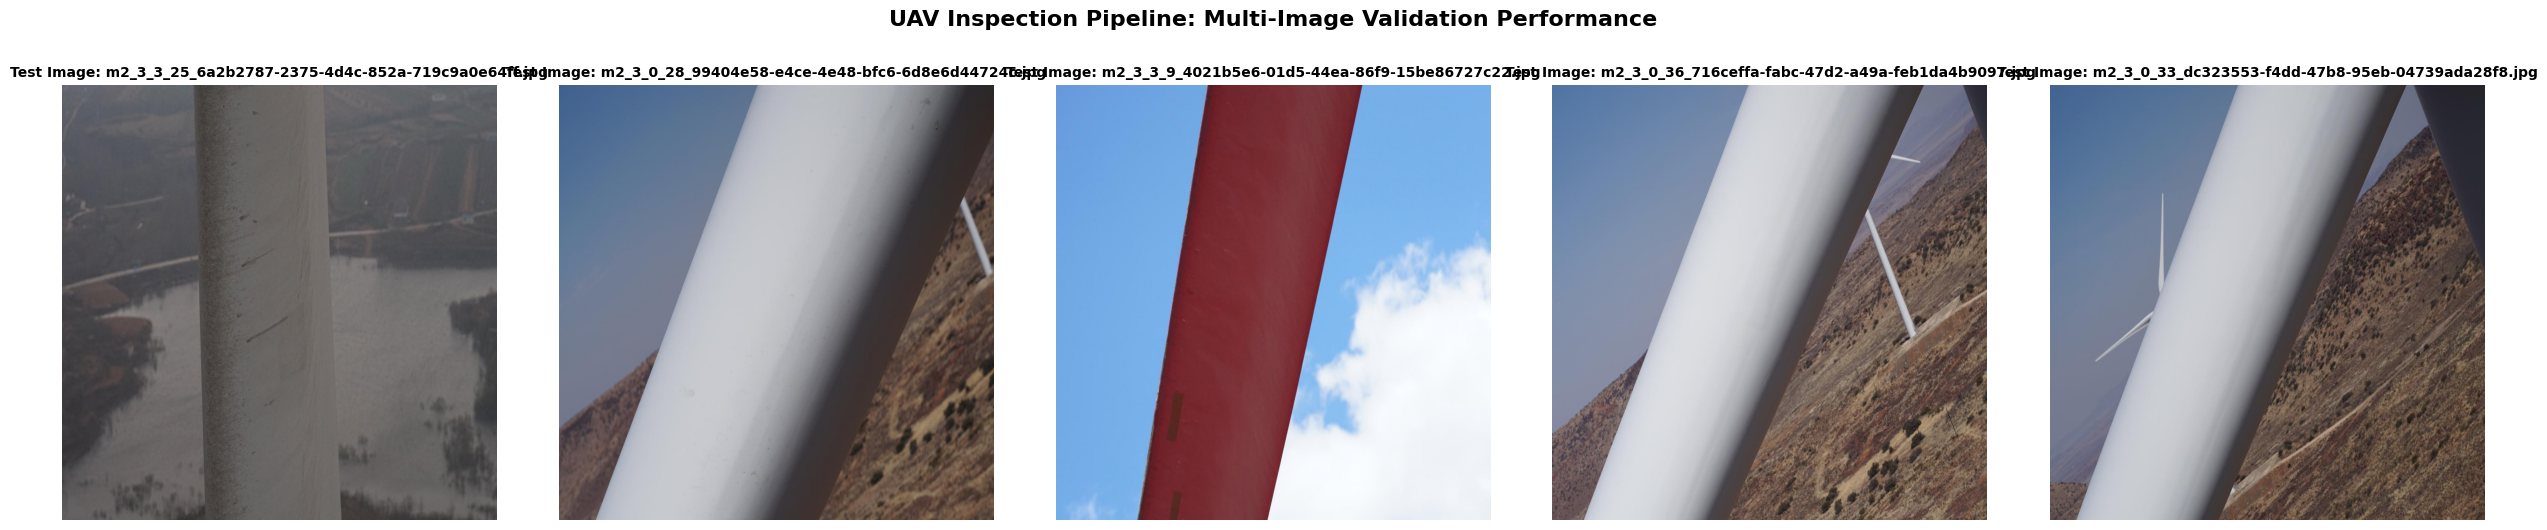

In [ ]:
import cv2
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pathlib import Path

# 1. Load the 50-epoch final model weights from your Google Drive
model_path = "/content/drive/MyDrive/Colab Notebooks/final_project/final_production_model_50_epochs.pt"
model = YOLO(model_path)

# 2. Gather all available validation images
test_img_dir = Path("/content/dataset/val/images")
all_images = list(test_img_dir.glob("*.jpg"))

if len(all_images) >= 5:
    # Randomly select 5 unique images from the pool to test generalization
    selected_images = random.sample(all_images, 5)

    # Set up a wide 1x5 grid plot for side-by-side report presentation
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))

    for i, img_path in enumerate(selected_images):
        # Perform visual prediction
        results = model.predict(source=str(img_path), imgsz=1024, conf=0.25, verbose=False)

        # Plot the bounding boxes onto the frame
        annotated_img = results[0].plot()
        annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

        # Render the image inside its specific grid column slot
        axes[i].imshow(annotated_img_rgb)
        axes[i].axis('off')
        axes[i].set_title(f"Test Image: {img_path.name}", fontsize=10, fontweight='bold')

    plt.suptitle("UAV Inspection Pipeline: Multi-Image Validation Performance", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ Not enough images. Found only {len(all_images)} pictures in your validation folder.")


In [ ]:
import hashlib

file_path = "/content/drive/MyDrive/Colab Notebooks/final_project/final_production_model_50_epochs.pt"
with open(file_path, "rb") as f:
    file_hash = hashlib.sha256(f.read()).hexdigest()

print("=== COLAB MODEL DIGITAL FINGERPRINT ===")
print(file_hash)


=== COLAB MODEL DIGITAL FINGERPRINT ===
fac80eae9c98626b4872f2e4f764d3a83b83b4768efe95313b8186f8faffd10b
